In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Data/funnel_Analysis_Data.csv')

print("Shape:", df.shape)
df.head(10)

Shape: (21409, 10)


,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes
5,USR-00003,SES-00003,2025-12-19 20:49:00.895328,Browse,Tablet,South,Email,Fashion,0.0,Yes
6,USR-00004,SES-00004,2026-01-08 07:58:00.840696,Browse,Tablet,East,Organic,Sports,0.0,Yes
7,USR-00004,SES-00004,2026-01-08 08:00:00.840696,Add to Cart,Tablet,East,Organic,Sports,0.0,Yes
8,USR-00004,SES-00004,2026-01-08 08:02:00.840696,Checkout,Tablet,East,Organic,Sports,0.0,Yes
9,USR-00005,SES-00005,2025-12-21 20:56:31.701462,Browse,Desktop,South,Google Ads,Beauty,0.0,Yes


In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nData Types:")
print(df.info())

Missing Values:
User ID             0
Session ID          0
Event Time          0
Event               0
Device              0
Region              0
Channel             0
Product Category    0
Revenue             0
Bonus Flag          0
dtype: int64

Duplicates: 0

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21409 entries, 0 to 21408
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User ID           21409 non-null  object 
 1   Session ID        21409 non-null  object 
 2   Event Time        21409 non-null  object 
 3   Event             21409 non-null  object 
 4   Device            21409 non-null  object 
 5   Region            21409 non-null  object 
 6   Channel           21409 non-null  object 
 7   Product Category  21409 non-null  object 
 8   Revenue           21409 non-null  float64
 9   Bonus Flag        21409 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.6+ M

In [4]:
# Remove spaces from column names
# Makes it easier to code with them

df.columns = df.columns.str.replace(' ', '_')

print("New column names:")
print(df.columns.tolist())

New column names:
['User_ID', 'Session_ID', 'Event_Time', 'Event', 'Device', 'Region', 'Channel', 'Product_Category', 'Revenue', 'Bonus_Flag']


In [5]:
# Convert Event_Time to proper datetime
df['Event_Time'] = pd.to_datetime(df['Event_Time'])

print("Event_Time dtype:", df['Event_Time'].dtype)
print("\nDate Range:")
print("From:", df['Event_Time'].min())
print("To:", df['Event_Time'].max())

Event_Time dtype: datetime64[ns]

Date Range:
From: 2025-12-09 15:42:28.549392
To: 2026-01-08 15:38:33.842791


In [6]:
print("Event Counts:")
print(df['Event'].value_counts())


Event Counts:
Event
Browse         10000
Add to Cart     6949
Checkout        3456
Purchase        1004
Name: count, dtype: int64


In [7]:
print("Total Unique Users:", df['User_ID'].nunique())
print("Total Unique Sessions:", df['Session_ID'].nunique())
print("Total Events:", len(df))

print("\nAvg events per user:", 
      round(len(df) / df['User_ID'].nunique(), 2))

Total Unique Users: 10000
Total Unique Sessions: 10000
Total Events: 21409

Avg events per user: 2.14


In [8]:
df.to_csv('Data/cleaned_funnel_data.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!


In [9]:
# Define funnel order
funnel_order = ['Browse', 'Add to Cart', 
                 'Checkout', 'Purchase']

# Count UNIQUE users at each stage
funnel_counts = df.groupby('Event')['User_ID'].nunique()

# Reorder by funnel stage
funnel_counts = funnel_counts.reindex(funnel_order)

print("Funnel Stage Counts (Unique Users):")
print(funnel_counts)


Funnel Stage Counts (Unique Users):
Event
Browse         10000
Add to Cart     6949
Checkout        3456
Purchase        1004
Name: User_ID, dtype: int64


In [10]:
funnel_df = pd.DataFrame({
    'Stage': funnel_order,
    'Users': funnel_counts.values
})

# Conversion rate from PREVIOUS stage
funnel_df['Conversion_from_Previous'] = (
    funnel_df['Users'] / funnel_df['Users'].shift(1) * 100
).round(2)

# Conversion rate from FIRST stage (Browse)
funnel_df['Conversion_from_Start'] = (
    funnel_df['Users'] / funnel_df['Users'].iloc[0] * 100
).round(2)

# Drop-off rate
funnel_df['Drop_Off_Rate'] = (
    100 - funnel_df['Conversion_from_Previous']
).round(2)

print("Complete Funnel Analysis:")
print(funnel_df)

# Fill the first row's NaN values
funnel_df['Conversion_from_Previous'] = (
    funnel_df['Conversion_from_Previous'].fillna(100))

funnel_df['Drop_Off_Rate'] = (
    funnel_df['Drop_Off_Rate'].fillna(0))

print("Fixed Funnel Table:")
print(funnel_df)

Complete Funnel Analysis:
         Stage  Users  Conversion_from_Previous  Conversion_from_Start  \
0       Browse  10000                       NaN                 100.00   
1  Add to Cart   6949                     69.49                  69.49   
2     Checkout   3456                     49.73                  34.56   
3     Purchase   1004                     29.05                  10.04   

   Drop_Off_Rate  
0            NaN  
1          30.51  
2          50.27  
3          70.95  
Fixed Funnel Table:
         Stage  Users  Conversion_from_Previous  Conversion_from_Start  \
0       Browse  10000                    100.00                 100.00   
1  Add to Cart   6949                     69.49                  69.49   
2     Checkout   3456                     49.73                  34.56   
3     Purchase   1004                     29.05                  10.04   

   Drop_Off_Rate  
0           0.00  
1          30.51  
2          50.27  
3          70.95  


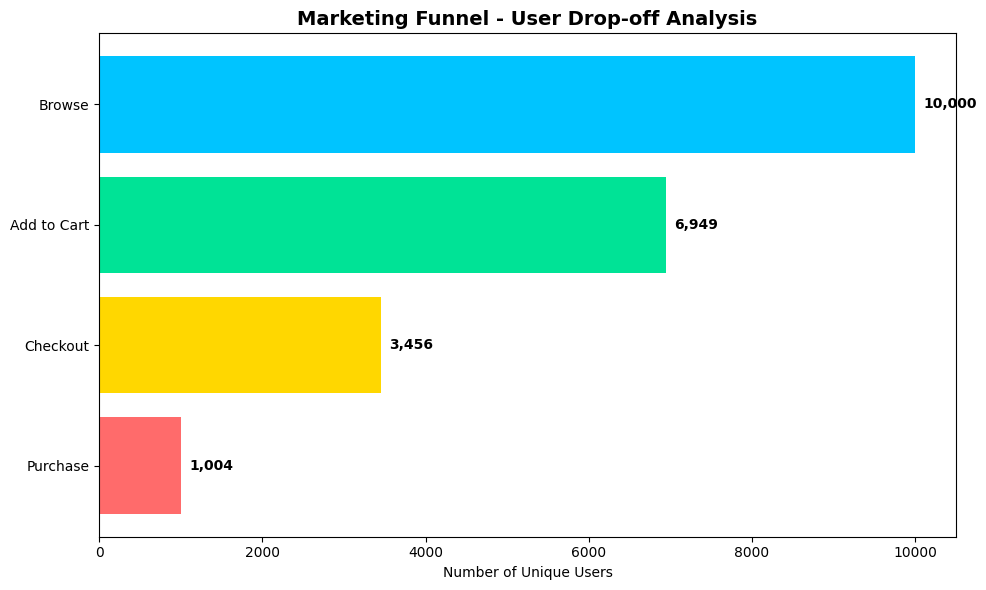

In [11]:
plt.figure(figsize=(10, 6))

colors = ['#00C4FF', '#00E396', '#FFD700', '#FF6B6B']

bars = plt.barh(funnel_df['Stage'], 
                 funnel_df['Users'],
                 color=colors)

# Add value labels
for i, (stage, users) in enumerate(
    zip(funnel_df['Stage'], funnel_df['Users'])):
    plt.text(users + 100, i, f'{users:,}', 
              va='center', fontweight='bold')

plt.title('Marketing Funnel - User Drop-off Analysis',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Unique Users')
plt.gca().invert_yaxis()  # Browse on top
plt.tight_layout()
plt.savefig('visuals/data_cleaning/funnel_chart.png')
plt.show()

In [12]:
# Build the same funnel logic, but split by Channel

channel_funnel = df.groupby(['Channel', 'Event'])['User_ID'].nunique().reset_index()
channel_funnel.columns = ['Channel', 'Event', 'Users']

# Pivot so each channel is a column, each stage is a row
channel_pivot = channel_funnel.pivot(
    index='Event', columns='Channel', values='Users')

# Reorder stages correctly
channel_pivot = channel_pivot.reindex(funnel_order)

print("Funnel by Channel (Unique Users):")
print(channel_pivot)

Funnel by Channel (Unique Users):
Channel      Email  Google Ads  Organic  Social Media
Event                                                
Browse        2515        2520     2528          2437
Add to Cart   1762        1746     1745          1696
Checkout       879         893      866           818
Purchase       248         268      239           249


In [13]:
# Overall conversion rate PER channel
channel_conversion = channel_pivot.loc['Purchase'] / channel_pivot.loc['Browse'] * 100
channel_conversion = channel_conversion.round(2).sort_values(ascending=False)

print("Overall Conversion Rate by Channel:")
print(channel_conversion)

Overall Conversion Rate by Channel:
Channel
Google Ads      10.63
Social Media    10.22
Email            9.86
Organic          9.45
dtype: float64


In [14]:
# Total traffic brought by each channel
channel_volume = df[df['Event']=='Browse'].groupby('Channel')['User_ID'].nunique()

# Combine volume + conversion rate together
channel_summary = pd.DataFrame({
    'Total_Traffic': channel_volume,
    'Conversion_Rate': channel_conversion
}).sort_values('Conversion_Rate', ascending=False)

print("Channel Volume vs Conversion Quality:")
print(channel_summary)

Channel Volume vs Conversion Quality:
              Total_Traffic  Conversion_Rate
Channel                                     
Google Ads             2520            10.63
Social Media           2437            10.22
Email                  2515             9.86
Organic                2528             9.45


In [15]:
# Revenue generated per channel
channel_revenue = df.groupby('Channel')['Revenue'].sum().reset_index()
channel_revenue.columns = ['Channel', 'Total_Revenue']
channel_revenue = channel_revenue.sort_values(
    'Total_Revenue', ascending=False)

print("Revenue by Channel:")
print(channel_revenue)

Revenue by Channel:
        Channel  Total_Revenue
1    Google Ads       73862.32
0         Email       69126.46
3  Social Media       68361.24
2       Organic       65973.04


In [16]:
# Average revenue per PURCHASE by channel
purchase_only = df[df['Event'] == 'Purchase']

avg_order = purchase_only.groupby('Channel')['Revenue'].mean().round(2)
avg_order = avg_order.sort_values(ascending=False)

print("Average Order Value by Channel:")
print(avg_order)

Average Order Value by Channel:
Channel
Email           278.74
Organic         276.04
Google Ads      275.61
Social Media    274.54
Name: Revenue, dtype: float64


In [17]:
# Does Bonus/Promo affect conversion?
bonus_funnel = df.groupby(
    ['Bonus_Flag', 'Event'])['User_ID'].nunique().reset_index()

bonus_pivot = bonus_funnel.pivot(
    index='Event', columns='Bonus_Flag', values='User_ID')
bonus_pivot = bonus_pivot.reindex(funnel_order)

print("Funnel by Bonus Flag:")
print(bonus_pivot)

# Conversion rate for bonus vs non-bonus
bonus_conv = bonus_pivot.loc['Purchase'] / bonus_pivot.loc['Browse'] * 100
print("\nConversion Rate:")
print(bonus_conv.round(2))

Funnel by Bonus Flag:
Bonus_Flag       No      Yes
Event                       
Browse          NaN  10000.0
Add to Cart     NaN   6949.0
Checkout        NaN   3456.0
Purchase     1004.0      NaN

Conversion Rate:
Bonus_Flag
No    NaN
Yes   NaN
dtype: float64


In [18]:
# Funnel by Device
device_funnel = df.groupby(
    ['Device', 'Event'])['User_ID'].nunique().reset_index()

device_pivot = device_funnel.pivot(
    index='Event', columns='Device', values='User_ID')
device_pivot = device_pivot.reindex(funnel_order)

print("Funnel by Device:")
print(device_pivot)

# Device conversion rates
device_conv = device_pivot.loc['Purchase'] / device_pivot.loc['Browse'] * 100
print("\nConversion Rate by Device:")
print(device_conv.round(2).sort_values(ascending=False))

Funnel by Device:
Device       Desktop  Mobile  Tablet
Event                               
Browse          3366    3263    3371
Add to Cart     2367    2253    2329
Checkout        1182    1123    1151
Purchase         356     309     339

Conversion Rate by Device:
Device
Desktop    10.58
Tablet     10.06
Mobile      9.47
dtype: float64


In [19]:
# Which category converts best?
category_funnel = df.groupby(
    ['Product_Category', 'Event'])['User_ID'].nunique().reset_index()

category_pivot = category_funnel.pivot(
    index='Event', columns='Product_Category', values='User_ID')
category_pivot = category_pivot.reindex(funnel_order)

print("Funnel by Product Category:")
print(category_pivot)

# Category conversion rates
cat_conv = category_pivot.loc['Purchase'] / category_pivot.loc['Browse'] * 100
print("\nConversion Rate by Category:")
print(cat_conv.round(2).sort_values(ascending=False))

Funnel by Product Category:
Product_Category  Beauty  Electronics  Fashion  Home  Sports
Event                                                       
Browse              2021         2052     2001  1978    1948
Add to Cart         1428         1443     1385  1357    1336
Checkout             713          711      692   666     674
Purchase             191          229      211   184     189

Conversion Rate by Category:
Product_Category
Electronics    11.16
Fashion        10.54
Sports          9.70
Beauty          9.45
Home            9.30
dtype: float64


In [20]:
# Save funnel summary
funnel_df.to_csv('Data/funnel_summary.csv', index=False)

# Save channel summary
channel_summary.to_csv('Data/channel_summary.csv', index=False)

# Save channel revenue
channel_revenue.to_csv('Data/channel_revenue.csv', index=False)

print("All files saved for Power BI!")

All files saved for Power BI!


In [21]:
# Check exact values in Bonus_Flag
print("Bonus Flag unique values:")
print(df['Bonus_Flag'].unique())

print("\nBonus Flag value counts:")
print(df['Bonus_Flag'].value_counts())

Bonus Flag unique values:
['Yes' 'No']

Bonus Flag value counts:
Bonus_Flag
Yes    20405
No      1004
Name: count, dtype: int64


In [22]:
# Fix 1 — Strip spaces
df['Bonus_Flag'] = df['Bonus_Flag'].str.strip()

# Fix 2 — Recalculate bonus funnel
bonus_funnel = df.groupby(
    ['Bonus_Flag', 'Event'])['User_ID'].nunique().reset_index()

bonus_pivot = bonus_funnel.pivot(
    index='Event', 
    columns='Bonus_Flag', 
    values='User_ID')
bonus_pivot = bonus_pivot.reindex(funnel_order)

print("Bonus Funnel:")
print(bonus_pivot)

# Conversion rate
bonus_conv = (bonus_pivot.loc['Purchase'] / 
              bonus_pivot.loc['Browse'] * 100).round(2)

print("\nConversion Rate by Bonus Flag:")
print(bonus_conv)

Bonus Funnel:
Bonus_Flag       No      Yes
Event                       
Browse          NaN  10000.0
Add to Cart     NaN   6949.0
Checkout        NaN   3456.0
Purchase     1004.0      NaN

Conversion Rate by Bonus Flag:
Bonus_Flag
No    NaN
Yes   NaN
dtype: float64


In [23]:
# Check one specific user
print("Sample user journey:")
print(df.groupby(['User_ID', 'Event', 
      'Bonus_Flag']).size().head(20))

# Check bonus distribution per event
print("\nBonus Flag per Event:")
print(df.groupby(['Event', 'Bonus_Flag']).size())

Sample user journey:
User_ID    Event        Bonus_Flag
USR-00001  Add to Cart  Yes           1
           Browse       Yes           1
           Checkout     Yes           1
USR-00002  Add to Cart  Yes           1
           Browse       Yes           1
USR-00003  Browse       Yes           1
USR-00004  Add to Cart  Yes           1
           Browse       Yes           1
           Checkout     Yes           1
USR-00005  Add to Cart  Yes           1
           Browse       Yes           1
           Checkout     Yes           1
           Purchase     No            1
USR-00006  Add to Cart  Yes           1
           Browse       Yes           1
USR-00007  Add to Cart  Yes           1
           Browse       Yes           1
           Checkout     Yes           1
USR-00008  Browse       Yes           1
USR-00009  Add to Cart  Yes           1
dtype: int64

Bonus Flag per Event:
Event        Bonus_Flag
Add to Cart  Yes            6949
Browse       Yes           10000
Checkout     Yes  

In [24]:
# Check what channel_summary looks like
print(channel_summary)
print(channel_summary.columns.tolist())

              Total_Traffic  Conversion_Rate
Channel                                     
Google Ads             2520            10.63
Social Media           2437            10.22
Email                  2515             9.86
Organic                2528             9.45
['Total_Traffic', 'Conversion_Rate']


In [25]:
# Reset index to make Channel a proper column
channel_summary_fixed = channel_summary.reset_index()

print("Fixed channel summary:")
print(channel_summary_fixed)
print("\nColumns:", channel_summary_fixed.columns.tolist())

# Save again
channel_summary_fixed.to_csv(
    'Data/channel_summary.csv', index=False)

print("Fixed file saved!")

Fixed channel summary:
        Channel  Total_Traffic  Conversion_Rate
0    Google Ads           2520            10.63
1  Social Media           2437            10.22
2         Email           2515             9.86
3       Organic           2528             9.45

Columns: ['Channel', 'Total_Traffic', 'Conversion_Rate']
Fixed file saved!
